Compute distances
$L_p$ distance between $(1,2)$ and $(3,4)$ for $p = 1,2, ∞$ and Chebyshev distance

In [1]:
# https://docs.scipy.org/doc/scipy/reference/spatial.distance.html

from scipy.spatial.distance import minkowski
from scipy.spatial.distance import chebyshev, cityblock
import math

x=(1,2)
y=(3,4)

print(f'cityblock {cityblock(x, y)}')
print(f'cityblock {minkowski(x, y, 1)}')
print(f'euclidean {minkowski(x, y, 2)}')

# L-1000 vs L-inf
print(f'L-1000 {minkowski(x, y, 1000)}')
print(f'L-inf {minkowski(x, y, math.inf)}')
print(f'chebyshev {chebyshev(x, y)}')

cityblock 4
cityblock 4.0
euclidean 2.8284271247461903
L-1000 2.0013867749251615
L-inf 2.0
chebyshev 2


b. Given two objects represented by the tuples $(22, 1, 42, 10)$ and $(20, 0, 36, 8)$:

1. Compute the Euclidean distance between the two objects.
2. Compute the Manhattan distance between the two objects.
3. Compute the Minkowski distance between the two objects, using $p = 3$.
4. Compute the supremum distance ($L_∞$) between the two objects.

In [2]:
x=(22,1,42,10)
y=(20,0,36,8)
print(f'Euclidean: {minkowski(x, y, 2)}')
print(f'City block: {minkowski(x, y, 1)}')
print(f'L-3: {minkowski(x, y, 3)}')
print(f'L-inf: {chebyshev(x, y)}')

Euclidean: 6.708203932499369
City block: 11.0
L-3: 6.153449493663682
L-inf: 6


Download the Ionosphere data set from the UCI Machine Learning Repository, remove the class feature and compute the $L_p$ distance between all pairs of data points, for $p=1,2,∞$.

Compute the contrast measure on the data set for the different norms.

Repeat the exercise after sampling the first $r$ dimensions, where $r$ varies from 1 to the full dimensionality of the data.

In [3]:
# https://archive.ics.uci.edu/dataset/52/ionosphere

import pandas as pd

path = '/Users/irene/OneDrive - UNIPA/UNIPA/DIDATTICA/BIG DATA TOOLS/2025/SLIDES 2025/OLD_exercises/5/_ionosphere/ionosphere.data'

labels=list(range(1, 35)) + ['class']
df = pd.read_csv(path, names=labels)
data = df.iloc[:, :-1].to_numpy(copy=True)
print(data.shape)

(351, 34)


In [4]:
data

array([[ 1.     ,  0.     ,  0.99539, ..., -0.54487,  0.18641, -0.453  ],
       [ 1.     ,  0.     ,  1.     , ..., -0.06288, -0.13738, -0.02447],
       [ 1.     ,  0.     ,  1.     , ..., -0.2418 ,  0.56045, -0.38238],
       ...,
       [ 1.     ,  0.     ,  0.94701, ...,  0.00442,  0.92697, -0.00577],
       [ 1.     ,  0.     ,  0.90608, ..., -0.03757,  0.87403, -0.16243],
       [ 1.     ,  0.     ,  0.8471 , ..., -0.06678,  0.85764, -0.06151]],
      shape=(351, 34))

In [4]:
import numpy as np

# compute all the distances from a single point to all the others
# thus obtainig a distances matrix
distances = np.zeros((3, data.shape[0],data.shape[0]))
for i in range(data.shape[0]):
    for j in range(data.shape[0]):
        distances[0][i][j] = minkowski(data[i, :], data[j, :], 1)
        distances[1][i][j] = minkowski(data[i, :], data[j, :], 2)
        distances[2][i][j] = chebyshev(data[i, :], data[j, :])
print(distances.shape)

(3, 351, 351)


In [5]:
# Constrast calculation along all the 351*351 distances
for p in range(3):
  print(f'Contrast {p} = {(distances[p].max()-distances[p].min())/distances[p].mean()}')

Contrast 0 = 2.637098523831358
Contrast 1 = 2.4486310913597125
Contrast 2 = 1.454402221815764


In [6]:
# constrast decreasing as incrementing number of considered dimensions
contrasts=np.zeros((3, data.shape[1]))

# incresing of r dimensions by 5
for r in range(5, data.shape[1], 5):
  i = 0
  distances = np.zeros((3, data.shape[0]*data.shape[0]))
  for d1 in data:
    for d2 in data:
        distances[0][i] = minkowski(d1[:r], d2[:r], 1)
        distances[1][i] = minkowski(d1[:r], d2[:r], 2)
        distances[2][i] = chebyshev(d1[:r], d2[:r])
        i += 1
  for p in range(3):
    contrasts[p, r] = (distances[p].max() - distances[p].min()) / distances[p].mean()

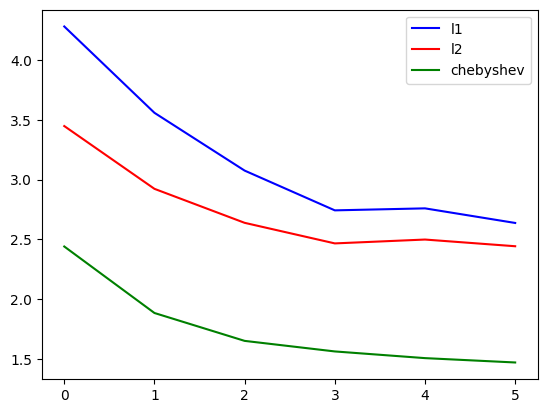

In [7]:
# Plot del contrasto al crescere di r
import matplotlib.pyplot as plt
plt.plot(contrasts[0, 5::5], 'blue')
plt.plot(contrasts[1, 5::5], 'red')
plt.plot(contrasts[2, 5::5], 'green')
plt.legend(['l1', 'l2', 'chebyshev'])